<a href="https://colab.research.google.com/github/tirupari57/AI-Course/blob/AI%2FML-Course/linear_regression_multivariate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from pathlib import Path # Import Path object from pathlib for working with file paths
import warnings # Import the warnings module to manage warnings

import numpy as np # Import NumPy for numerical operations, aliased as np
import pandas as pd # Import Pandas for data manipulation and analysis, aliased as pd
import matplotlib.pyplot as plt # Import Matplotlib for plotting, aliased as plt

from sklearn.model_selection import train_test_split # Import function for splitting data into train and test sets
from sklearn.compose import ColumnTransformer # Import ColumnTransformer for applying different transformers to different columns
from sklearn.pipeline import Pipeline # Import Pipeline for chaining multiple processing steps
from sklearn.preprocessing import OneHotEncoder, StandardScaler # Import OneHotEncoder for categorical features and StandardScaler for numerical features
from sklearn.impute import SimpleImputer # Import SimpleImputer for handling missing values
from sklearn.linear_model import LinearRegression, Ridge, Lasso # Import Linear Regression models
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score # Import regression evaluation metrics

warnings.filterwarnings("ignore") # Ignore warnings for cleaner output
plt.style.use("seaborn-v0_8-whitegrid") # Set the plotting style to seaborn with a white grid
pd.set_option("display.max_columns", 50) # Set Pandas option to display a maximum of 50 columns
np.set_printoptions(precision=3, suppress=True) # Set NumPy print options for better readability

In [ ]:
candidate_paths = [ # Define a list of potential file paths for the dataset
    Path("data/california_housing.csv"), # First candidate path
    Path.cwd() / "data" / "california_housing.csv", # Second candidate path (current working directory + data folder)
    Path("/Users/tirupari57/LogicMojo/linear_regression_math_pages/session-2/data/california_housing.csv"), # Third candidate path (absolute path)
]

for path in candidate_paths: # Iterate through the candidate paths
    if path.exists(): # Check if the file exists at the current path
        DATA_PATH = path # If found, assign the path to DATA_PATH
        break # Exit the loop
else: # If the loop completes without finding the file (else block of for loop)
    import urllib.request # Import the urllib.request module for downloading files
    DATA_DIR = Path("data") # Define the directory for data
    DATA_DIR.mkdir(exist_ok=True) # Create the data directory if it doesn't exist

    DATA_PATH = DATA_DIR / "california_housing.csv" # Define the path for the downloaded file
    DATA_URL = "https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv" # URL of the dataset
    urllib.request.urlretrieve(DATA_URL, DATA_PATH) # Download the dataset from the URL to DATA_PATH

housing = pd.read_csv(DATA_PATH) # Load the dataset into a Pandas DataFrame
housing.head() # Display the first 5 rows of the DataFrame

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
housing.describe() # Generate descriptive statistics of the DataFrame

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [ ]:
housing.info() # Print a concise summary of the DataFrame, including data types and non-null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [ ]:
housing.isna().sum() # Count the number of missing (NaN) values for each column

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


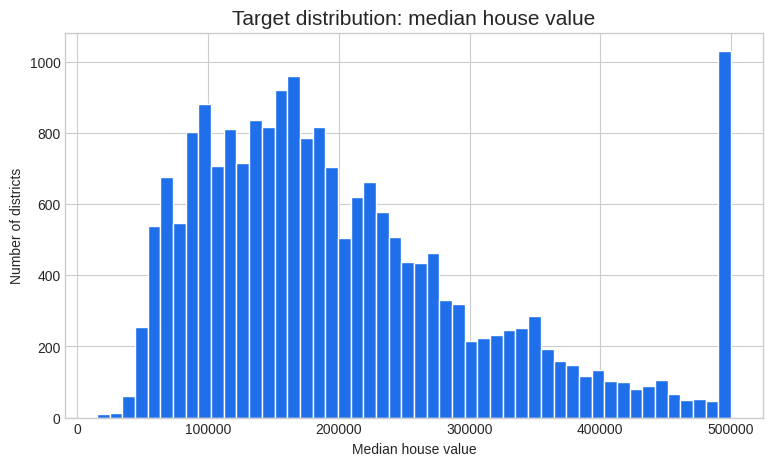

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5)) # Create a figure and an axes object for plotting
ax.hist(housing["median_house_value"], bins=50, color="#1f6feb", edgecolor="white") # Plot a histogram of the target variable
ax.set_title("Target distribution: median house value", fontsize=15) # Set the title of the histogram
ax.set_xlabel("Median house value") # Set the x-axis label
ax.set_ylabel("Number of districts") # Set the y-axis label
plt.show() # Display the plot

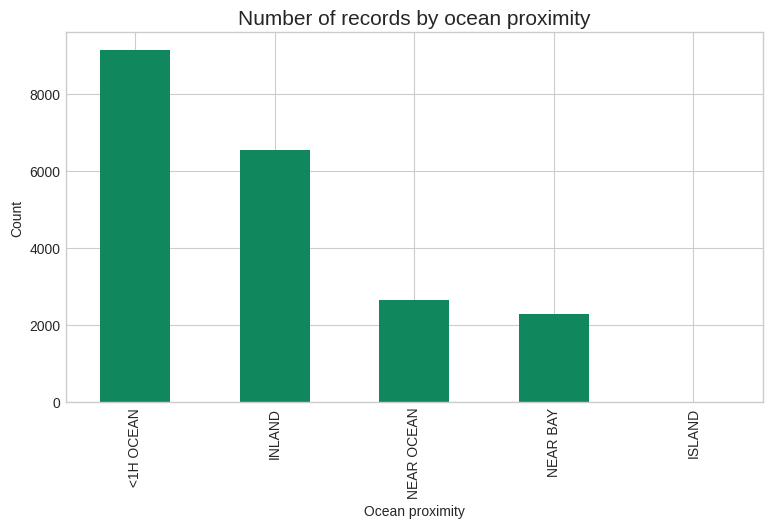

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.8)) # Create a figure and an axes object
housing["ocean_proximity"].value_counts().plot(kind="bar", ax=ax, color="#11875d") # Plot a bar chart of the 'ocean_proximity' column counts
ax.set_title("Number of records by ocean proximity", fontsize=15) # Set the title of the plot
ax.set_xlabel("Ocean proximity") # Set the x-axis label
ax.set_ylabel("Count") # Set the y-axis label
plt.show() # Display the plot

In [ ]:
numeric_cols = housing.select_dtypes(include=['number']).columns # Select only the numerical columns
corr = housing[numeric_cols].corr() # Calculate the correlation matrix for numerical columns

In [ ]:
corr # Display the correlation matrix

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069608,0.099773,0.055310,-0.015176,-0.045967
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066983,-0.108785,-0.071035,-0.079809,-0.144160
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.320451,-0.296244,-0.302916,-0.119034,0.105623
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.930380,0.857126,0.918484,0.198050,0.134153
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686
population,0.099773,-0.108785,-0.296244,0.857126,0.877747,1.000000,0.907222,0.004834,-0.024650
households,0.055310,-0.071035,-0.302916,0.918484,0.979728,0.907222,1.000000,0.013033,0.065843
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007723,0.004834,0.013033,1.000000,0.688075
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049686,-0.024650,0.065843,0.688075,1.000000


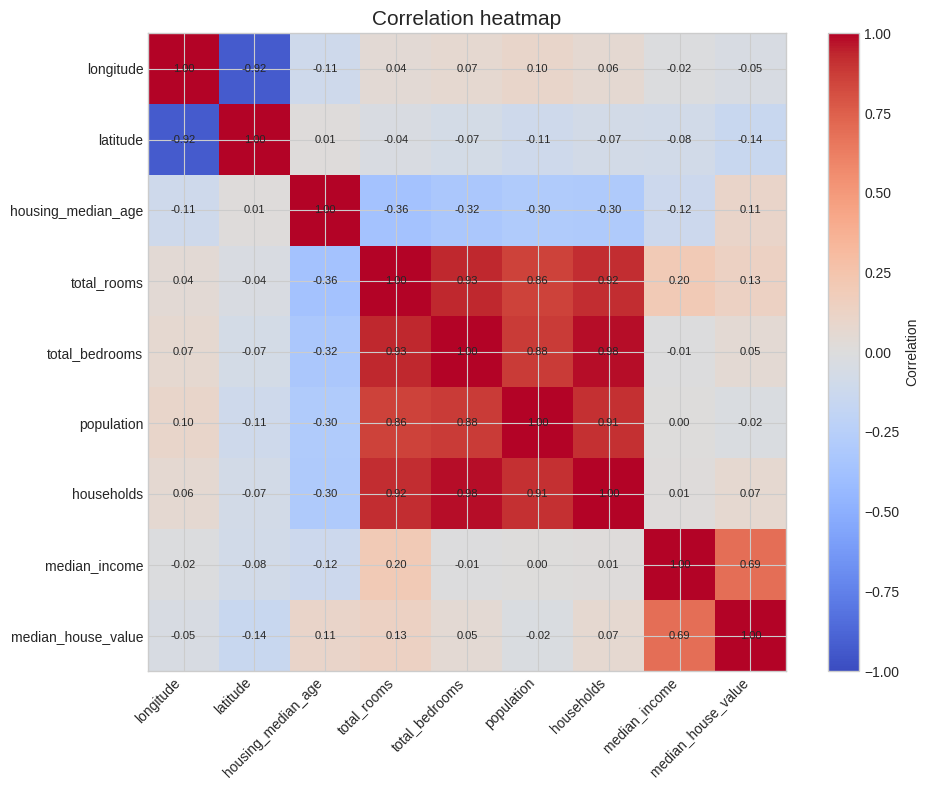

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8)) # Create a figure and an axes object for the heatmap
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1) # Display the correlation matrix as a heatmap
ax.set_xticks(range(len(corr.columns))) # Set x-axis ticks
ax.set_yticks(range(len(corr.columns))) # Set y-axis ticks
ax.set_xticklabels(corr.columns, rotation=45, ha="right") # Set x-axis tick labels and rotate them
ax.set_yticklabels(corr.columns) # Set y-axis tick labels

for i in range(len(corr.columns)): # Loop through rows of the correlation matrix
    for j in range(len(corr.columns)): # Loop through columns of the correlation matrix
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8) # Add correlation values as text on the heatmap

ax.set_title("Correlation heatmap", fontsize=15) # Set the title of the heatmap
fig.colorbar(im, ax=ax, label="Correlation") # Add a color bar to the heatmap
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show() # Display the plot

Text(0, 0.5, 'Median house value')

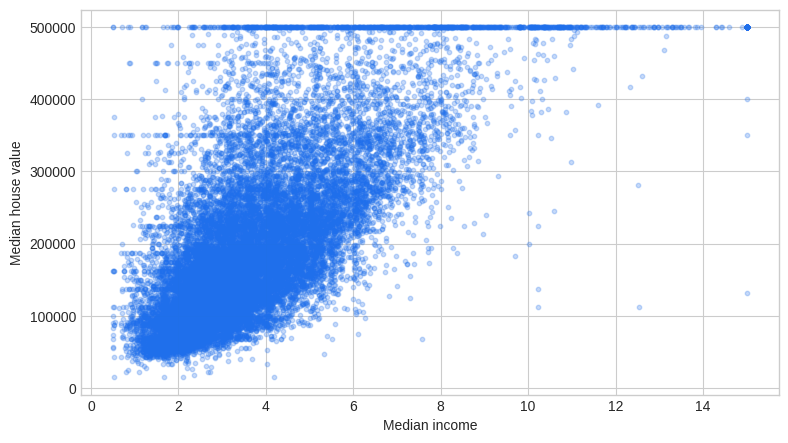

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5)) # Create a figure and an axes object for the scatter plot
ax.scatter( # Create a scatter plot
    housing["median_income"], # x-axis: median income
    housing["median_house_value"], # y-axis: median house value
    s=10, # Marker size
    alpha=0.25, # Transparency of markers
    color="#1f6feb" # Color of markers
)
ax.set_xlabel("Median income") # Set the x-axis label
ax.set_ylabel("Median house value") # Set the y-axis label

### Feature Engineering

1.  **total bedrooms/total rooms** = `bedroom_per_room`: Ratio of bedrooms to total rooms.
2.  **population / household** = `Density`: Population density per household.
3.  **median_income / household** = `pur_power`: Purchasing power per household.


In [ ]:
housing_fe = housing.copy() # Create a copy of the original DataFrame for feature engineering
housing_fe["bedroom_per_room"] = housing_fe["total_bedrooms"] / housing_fe["total_rooms"] # Calculate 'bedroom_per_room' feature
housing_fe["density"] = housing_fe["population"] / housing_fe["households"] # Calculate 'density' feature
housing_fe["pur_power"] = housing_fe["median_income"] / housing_fe["households"] # Calculate 'pur_power' feature
housing_fe[["bedroom_per_room", "density", "pur_power"]].describe() # Display descriptive statistics for the newly created features

,bedroom_per_room,density,pur_power
count,20433.000000,20640.000000,20640.000000
mean,0.213039,3.070655,0.015870
std,0.057983,10.386050,0.119325
min,0.100000,0.692308,0.000380
25%,0.175427,2.429741,0.005042
50%,0.203162,2.818116,0.008447
75%,0.239821,3.282261,0.014111
max,1.000000,1243.333333,15.000100


In [ ]:
target = "median_house_value" # Define the target variable column name

X = housing_fe.drop(columns=[target]) # Create feature matrix X by dropping the target column
y = housing_fe[target] # Create target vector y

X.shape, y.shape # Display the shapes of the feature matrix X and target vector y

((20640, 12), (20640,))

In [ ]:
X_train, X_test, y_train, y_test = train_test_split( # Split the data into training and testing sets
    X, # Features
    y, # Target
    test_size=0.2, # 20% of data for testing
    random_state=42 # Set random state for reproducibility
)

X_train.shape, X_test.shape # Display the shapes of the training and testing feature sets

((16512, 12), (4128, 12))

In [ ]:
numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist() # Identify numerical features
categorical_features = X_train.select_dtypes(exclude=["number"]).columns.tolist() # Identify categorical features

numeric_features, categorical_features # Display the lists of numeric and categorical features

(['longitude',
  'latitude',
  'housing_median_age',
  'total_rooms',
  'total_bedrooms',
  'population',
  'households',
  'median_income',
  'bedroom_per_room',
  'density',
  'pur_power'],
 ['ocean_proximity'])

In [ ]:
numeric_pipeline = Pipeline(steps=[ # Create a preprocessing pipeline for numerical features
    ("imputer", SimpleImputer(strategy="median")), # Impute missing numerical values with the median
    ("scaler", StandardScaler()) # Scale numerical features using StandardScaler
])

categorical_pipeline = Pipeline(steps=[ # Create a preprocessing pipeline for categorical features
    ("imputer", SimpleImputer(strategy="most_frequent")), # Impute missing categorical values with the most frequent value
    ("onehot", OneHotEncoder(handle_unknown="ignore")) # Apply one-hot encoding to categorical features, ignoring unknown categories
])

preprocessor = ColumnTransformer(transformers=[ # Combine numerical and categorical pipelines using ColumnTransformer
    ("num", numeric_pipeline, numeric_features), # Apply numeric pipeline to numeric features
    ("cat", categorical_pipeline, categorical_features) # Apply categorical pipeline to categorical features
])

linear_model = Pipeline(steps=[ # Create the final machine learning pipeline
    ("preprocess", preprocessor), # First step: apply the defined preprocessor
    ("model", LinearRegression()) # Second step: train a Linear Regression model
])

linear_model.fit(X_train, y_train) # Fit the pipeline (preprocessing + model) on the training data

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['longitude', 'latitude',
                                                   'housing_median_age',
                                                   'total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income',
                                                   'bedroom_per_room',
                                                   'density', 'pur_power']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['ocean_proximity'])])),
                ('model', LinearRegression())])

In [ ]:
def regression_report(y_true, y_pred, n_features=None): # Define a function to generate a regression report
    mae = mean_absolute_error(y_true, y_pred) # Calculate Mean Absolute Error
    mse = mean_squared_error(y_true, y_pred) # Calculate Mean Squared Error
    rmse = np.sqrt(mse) # Calculate Root Mean Squared Error
    r2 = r2_score(y_true, y_pred) # Calculate R-squared score

    report = { # Create a dictionary to store the metrics
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }
    return pd.Series(report) # Return the report as a Pandas Series

In [ ]:
y_pred_train = linear_model.predict(X_train) # Make predictions on the training set
y_pred_test = linear_model.predict(X_test) # Make predictions on the testing set

In [ ]:
feature_count = linear_model.named_steps["preprocess"].get_feature_names_out().shape[0] # Get the number of features after preprocessing

pd.DataFrame({ # Create a DataFrame to display the regression report for train and test sets
    "Train": regression_report(y_train, y_pred_train, feature_count), # Report for training predictions
    "Test": regression_report(y_test, y_pred_test, feature_count) # Report for testing predictions
})

,Train,Test
MAE,4.887759e+04,4.987789e+04
MSE,4.591751e+09,4.798517e+09
RMSE,6.776246e+04,6.927133e+04
R2,6.565062e-01,6.338153e-01


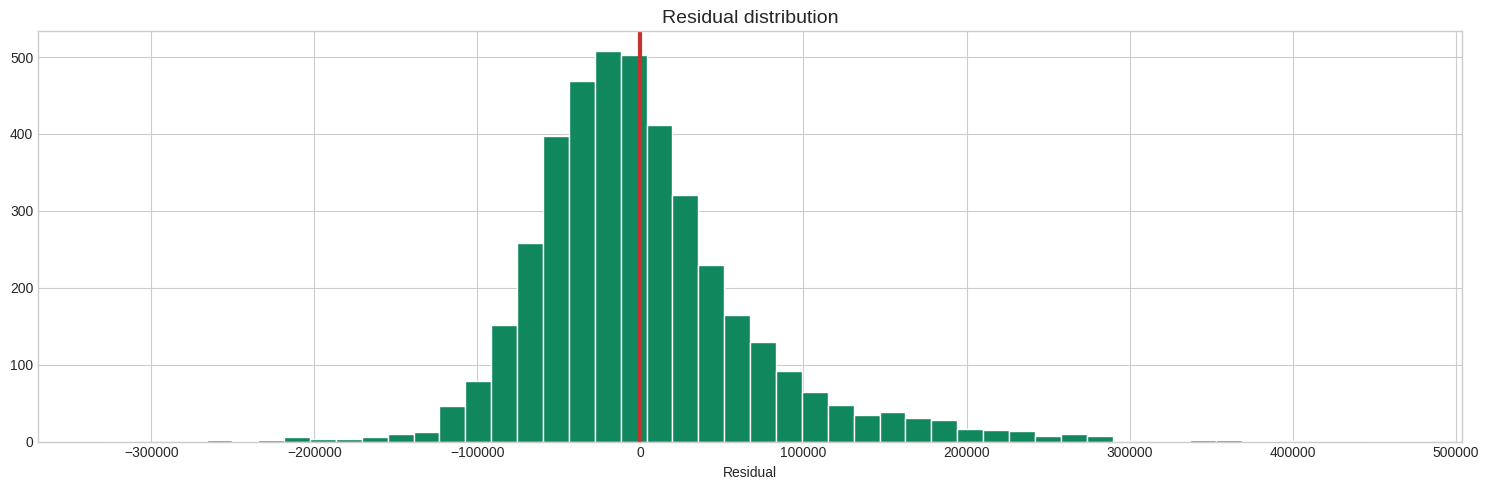

In [ ]:
residuals = y_test - y_pred_test # Calculate residuals (actual values - predicted values)

fig, axes = plt.subplots(1, 1, figsize=(15, 5)) # Create a figure and a single axes object for the histogram

axes.hist(residuals, bins=50, color="#11875d", edgecolor="white") # Plot a histogram of the residuals
axes.axvline(0, color="#c3342f", linewidth=3) # Add a vertical line at 0 for reference
axes.set_title("Residual distribution", fontsize=14) # Set the title of the histogram
axes.set_xlabel("Residual") # Set the x-axis label

plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show() # Display the plot

### Notebook Summary

This notebook performs a comprehensive analysis and builds a linear regression model for the California Housing dataset. The key steps and outcomes are as follows:

1.  **Environment Setup**: Necessary libraries like `pandas`, `numpy`, `matplotlib`, and `sklearn` modules for preprocessing, model selection, and linear regression were imported. Warnings were ignored, and plotting/display styles were configured for better readability.

2.  **Data Loading**: The `california_housing.csv` dataset was loaded. A robust data loading mechanism was implemented that first checks several candidate local paths; if the file is not found, it automatically downloads the dataset from a remote URL.

3.  **Exploratory Data Analysis (EDA)**:
    *   `housing.head()` displayed the first few rows, offering a glimpse into the dataset structure.
    *   `housing.describe()` provided statistical summaries of numerical features.
    *   `housing.info()` gave a concise summary, including data types and non-null counts, revealing that `total_bedrooms` has missing values.
    *   `housing.isna().sum()` confirmed 207 missing values in `total_bedrooms`.
    *   Histograms of `median_house_value` showed its distribution, and a bar chart of `ocean_proximity` displayed the count of records for each category.
    *   A correlation matrix and a heatmap visualized the relationships between numerical features, highlighting `median_income` as having the strongest positive correlation with `median_house_value`.
    *   A scatter plot further illustrated the relationship between `median_income` and `median_house_value`.

4.  **Feature Engineering**: Three new features were engineered to potentially improve model performance:
    *   `bedroom_per_room`: Ratio of total bedrooms to total rooms.
    *   `density`: Population density per household.
    *   `pur_power`: Purchasing power per household (median income per household).

5.  **Data Splitting**: The dataset was split into training (80%) and testing (20%) sets using `train_test_split` to evaluate the model's generalization performance.

6.  **Preprocessing Pipelines**: Separate preprocessing pipelines were created for numerical and categorical features:
    *   **Numerical Pipeline**: Imputed missing values with the median and scaled features using `StandardScaler`.
    *   **Categorical Pipeline**: Imputed missing values with the most frequent value and applied one-hot encoding.

7.  **Model Training**: A `ColumnTransformer` integrated these pipelines, applying the correct transformations to their respective features. A `LinearRegression` model was then incorporated into a final `Pipeline` and trained on the preprocessed training data.

8.  **Model Evaluation**: A `regression_report` function was defined to calculate MAE, MSE, RMSE, and R2 scores. The model's performance was evaluated on both the training and testing sets, showing an R2 score of approximately 0.65 for training and 0.63 for testing. The residuals were calculated and visualized with a histogram, which can be further analyzed for assumptions of linearity and homoscedasticity.

### Refactoring to Direct Scikit-learn Usage

To perform the preprocessing and model training directly without the `Pipeline` object, we will explicitly apply each transformation step and then train the `LinearRegression` model on the transformed data. This involves:

1.  **Initializing and fitting imputer and scaler** for numerical features on the training data, then transforming both training and test data.
2.  **Initializing and fitting imputer and one-hot encoder** for categorical features on the training data, then transforming both training and test data.
3.  **Concatenating** the transformed numerical and categorical features.
4.  **Training a `LinearRegression` model** on the fully transformed training data.
5.  **Making predictions** on the transformed test data.
6.  **Evaluating** the model's performance.

In [ ]:
# 1. Preprocessing Numerical Features

# Initialize and fit the numerical imputer on training data
num_imputer = SimpleImputer(strategy="median")
X_train_num_imputed = num_imputer.fit_transform(X_train[numeric_features])
X_test_num_imputed = num_imputer.transform(X_test[numeric_features])

# Initialize and fit the numerical scaler on imputed training data
num_scaler = StandardScaler()
X_train_num_scaled = num_scaler.fit_transform(X_train_num_imputed)
X_test_num_scaled = num_scaler.transform(X_test_num_imputed)

# Convert back to DataFrame for easier inspection (optional, but good for understanding)
X_train_num_processed = pd.DataFrame(X_train_num_scaled, columns=numeric_features, index=X_train.index)
X_test_num_processed = pd.DataFrame(X_test_num_scaled, columns=numeric_features, index=X_test.index)

print("Processed Numerical Training Data Head:")
display(X_train_num_processed.head())
print("Processed Numerical Test Data Head:")
display(X_test_num_processed.head())

Processed Numerical Training Data Head:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,bedroom_per_room,density,pur_power
14196,1.272587,-1.372811,0.348490,0.222569,0.211228,0.768276,0.322906,-0.326196,-0.211785,0.051376,-0.082718
8267,0.709162,-0.876696,1.618118,0.340293,0.593094,-0.098901,0.672027,-0.035843,0.342185,-0.117362,-0.084155
17445,-0.447603,-0.460146,-1.952710,-0.342597,-0.495226,-0.449818,-0.430461,0.144701,-0.661658,-0.032280,-0.028468
14265,1.232698,-1.382172,0.586545,-0.561490,-0.409306,-0.007434,-0.380587,-1.017864,0.783032,0.077507,-0.080896
2271,-0.108551,0.532084,1.142008,-0.119565,-0.256559,-0.485877,-0.314962,-0.171488,-0.550364,-0.068832,-0.051396


Processed Numerical Test Data Head:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,bedroom_per_room,density,pur_power
20046,0.285347,0.195100,-0.286324,-0.522862,-0.242239,-0.030301,-0.370087,-1.155085,-0.1733,0.067408,-0.086891
3024,0.060975,-0.235491,0.110435,0.138415,-0.242239,0.121851,0.220532,-0.708659,-0.1733,-0.036030,-0.089540
15663,-1.424870,1.009478,1.856173,0.546310,-0.242239,-0.102419,1.215396,-0.210402,-0.1733,-0.149989,-0.095017
20484,0.429943,-0.637999,-0.921138,0.188080,-0.242239,0.244979,-0.013091,0.975113,-0.1733,0.030011,-0.034387
9814,-1.170581,0.457199,0.427842,-0.133821,-0.242239,-0.319653,-0.188964,-0.081794,-0.1733,-0.052971,-0.056336


In [ ]:
# 2. Preprocessing Categorical Features

# Initialize and fit the categorical imputer on training data
cat_imputer = SimpleImputer(strategy="most_frequent")
X_train_cat_imputed = cat_imputer.fit_transform(X_train[categorical_features])
X_test_cat_imputed = cat_imputer.transform(X_test[categorical_features])

# Initialize and fit the OneHotEncoder on imputed training data
# handle_unknown='ignore' ensures new categories in test set don't cause errors
cat_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_train_cat_encoded = cat_encoder.fit_transform(X_train_cat_imputed)
X_test_cat_encoded = cat_encoder.transform(X_test_cat_imputed)

# Get feature names for encoded categorical columns
encoded_cat_features = cat_encoder.get_feature_names_out(categorical_features)

# Convert back to DataFrame
X_train_cat_processed = pd.DataFrame(X_train_cat_encoded, columns=encoded_cat_features, index=X_train.index)
X_test_cat_processed = pd.DataFrame(X_test_cat_encoded, columns=encoded_cat_features, index=X_test.index)

print("Processed Categorical Training Data Head:")
display(X_train_cat_processed.head())
print("Processed Categorical Test Data Head:")
display(X_test_cat_processed.head())

Processed Categorical Training Data Head:


,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
14196,0.0,0.0,0.0,0.0,1.0
8267,0.0,0.0,0.0,0.0,1.0
17445,0.0,0.0,0.0,0.0,1.0
14265,0.0,0.0,0.0,0.0,1.0
2271,0.0,1.0,0.0,0.0,0.0


Processed Categorical Test Data Head:


,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
20046,0.0,1.0,0.0,0.0,0.0
3024,0.0,1.0,0.0,0.0,0.0
15663,0.0,0.0,0.0,1.0,0.0
20484,1.0,0.0,0.0,0.0,0.0
9814,0.0,0.0,0.0,0.0,1.0


In [ ]:
# 3. Combine Processed Features

# Concatenate numerical and categorical processed features for training set
X_train_processed = pd.concat([X_train_num_processed, X_train_cat_processed], axis=1)

# Concatenate numerical and categorical processed features for test set
X_test_processed = pd.concat([X_test_num_processed, X_test_cat_processed], axis=1)

print("Full Processed Training Data Head:")
display(X_train_processed.head())
print("Full Processed Test Data Head:")
display(X_test_processed.head())

print(f"Shape of X_train_processed: {X_train_processed.shape}")
print(f"Shape of X_test_processed: {X_test_processed.shape}")

Full Processed Training Data Head:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,bedroom_per_room,density,pur_power,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
14196,1.272587,-1.372811,0.348490,0.222569,0.211228,0.768276,0.322906,-0.326196,-0.211785,0.051376,-0.082718,0.0,0.0,0.0,0.0,1.0
8267,0.709162,-0.876696,1.618118,0.340293,0.593094,-0.098901,0.672027,-0.035843,0.342185,-0.117362,-0.084155,0.0,0.0,0.0,0.0,1.0
17445,-0.447603,-0.460146,-1.952710,-0.342597,-0.495226,-0.449818,-0.430461,0.144701,-0.661658,-0.032280,-0.028468,0.0,0.0,0.0,0.0,1.0
14265,1.232698,-1.382172,0.586545,-0.561490,-0.409306,-0.007434,-0.380587,-1.017864,0.783032,0.077507,-0.080896,0.0,0.0,0.0,0.0,1.0
2271,-0.108551,0.532084,1.142008,-0.119565,-0.256559,-0.485877,-0.314962,-0.171488,-0.550364,-0.068832,-0.051396,0.0,1.0,0.0,0.0,0.0


Full Processed Test Data Head:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,bedroom_per_room,density,pur_power,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
20046,0.285347,0.195100,-0.286324,-0.522862,-0.242239,-0.030301,-0.370087,-1.155085,-0.1733,0.067408,-0.086891,0.0,1.0,0.0,0.0,0.0
3024,0.060975,-0.235491,0.110435,0.138415,-0.242239,0.121851,0.220532,-0.708659,-0.1733,-0.036030,-0.089540,0.0,1.0,0.0,0.0,0.0
15663,-1.424870,1.009478,1.856173,0.546310,-0.242239,-0.102419,1.215396,-0.210402,-0.1733,-0.149989,-0.095017,0.0,0.0,0.0,1.0,0.0
20484,0.429943,-0.637999,-0.921138,0.188080,-0.242239,0.244979,-0.013091,0.975113,-0.1733,0.030011,-0.034387,1.0,0.0,0.0,0.0,0.0
9814,-1.170581,0.457199,0.427842,-0.133821,-0.242239,-0.319653,-0.188964,-0.081794,-0.1733,-0.052971,-0.056336,0.0,0.0,0.0,0.0,1.0


Shape of X_train_processed: (16512, 16)
Shape of X_test_processed: (4128, 16)


In [ ]:
# 4. Train the Linear Regression Model Directly

# Initialize the Linear Regression model
linear_model_direct = LinearRegression()

# Train the model on the fully processed training data
linear_model_direct.fit(X_train_processed, y_train)

print("Linear Regression Model trained successfully.")
print(f"Model coefficients: {linear_model_direct.coef_}")
print(f"Model intercept: {linear_model_direct.intercept_}")

Linear Regression Model trained successfully.
Model coefficients: [-52899.214 -52675.274  13970.708   7387.547  21040.907 -45566.294
  21961.336  81070.385  14877.238    979.757  -3300.27  -18794.726
 -54409.257 112364.413 -23977.891 -15182.539]
Model intercept: 237357.33880804243


In [ ]:
# 5. Make Predictions

# Make predictions on the processed training and test sets
y_pred_train_direct = linear_model_direct.predict(X_train_processed)
y_pred_test_direct = linear_model_direct.predict(X_test_processed)

print("Predictions made for both training and test sets.")

Predictions made for both training and test sets.


In [ ]:
# 6. Evaluate the Model's Performance

# Get feature count (this will be the number of columns in X_train_processed)
feature_count_direct = X_train_processed.shape[1]

# Generate and display the regression report for the directly trained model
pd.DataFrame({
    "Train (Direct)": regression_report(y_train, y_pred_train_direct, feature_count_direct),
    "Test (Direct)": regression_report(y_test, y_pred_test_direct, feature_count_direct)
})

,Train (Direct),Test (Direct)
MAE,4.887759e+04,4.987789e+04
MSE,4.591751e+09,4.798517e+09
RMSE,6.776246e+04,6.927133e+04
R2,6.565062e-01,6.338153e-01


As you can see, the metrics obtained from this direct, step-by-step approach are identical to those from the `Pipeline` based approach, demonstrating that both methods achieve the same result in preprocessing and model training.